<a href="https://colab.research.google.com/github/sharvaripd/DL-/blob/main/ANN1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Solving Churn Modelling using ANN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
df=pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# Select input and output
x= df.iloc[:,3:-1]
y= df.iloc[:,-1]
print(x.head())
print(y.head())

   CreditScore Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619    France  Female   42       2       0.00              1   
1          608     Spain  Female   41       1   83807.86              1   
2          502    France  Female   42       8  159660.80              3   
3          699    France  Female   39       1       0.00              2   
4          850     Spain  Female   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  
0          1               1        101348.88  
1          0               1        112542.58  
2          1               0        113931.57  
3          0               0         93826.63  
4          1               1         79084.10  
0    1
1    0
2    1
3    0
4    0
Name: Exited, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder
# Data Preprocessing
x['Geography']=LabelEncoder().fit_transform(x['Geography'])
x['Gender']=LabelEncoder().fit_transform(x['Gender'])
print(x.head())

   CreditScore  Geography  Gender  Age  Tenure    Balance  NumOfProducts  \
0          619          0       0   42       2       0.00              1   
1          608          2       0   41       1   83807.86              1   
2          502          0       0   42       8  159660.80              3   
3          699          0       0   39       1       0.00              2   
4          850          2       0   43       2  125510.82              1   

   HasCrCard  IsActiveMember  EstimatedSalary  
0          1               1        101348.88  
1          0               1        112542.58  
2          1               0        113931.57  
3          0               0         93826.63  
4          1               1         79084.10  


In [ ]:
# Train Test Split of the data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape,x_test.shape)
print(y_train.shape,y_test.shape)

(8000, 10) (2000, 10)
(8000,) (2000,)


In [ ]:
# Feature Scaling
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
# Building ANN
ann=Sequential()
ann.add(Dense(units=6,activation='relu')) # Unit represents the number of perceptrons
ann.add(Dense(units=6,activation='relu')) # Hidden Layer
ann.add(Dense(units=1,activation='sigmoid')) # Output Layer

In [ ]:
#Compile
ann.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [ ]:
#Train
history=ann.fit(x_train,y_train,batch_size=32,epochs=100,validation_split=0.20)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7437 - loss: 0.5661 - val_accuracy: 0.7981 - val_loss: 0.5002
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7934 - loss: 0.4803 - val_accuracy: 0.8000 - val_loss: 0.4641
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7973 - loss: 0.4586 - val_accuracy: 0.8175 - val_loss: 0.4457
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8083 - loss: 0.4464 - val_accuracy: 0.8206 - val_loss: 0.4349
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8130 - loss: 0.4394 - val_accuracy: 0.8194 - val_loss: 0.4292
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8158 - loss: 0.4342 - val_accuracy: 0.8213 - val_loss: 0.4247
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8177 - loss: 0.4299 - val_accuracy: 0.8219 - val_loss: 0.4214
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8202 - loss: 0.4252 - val_accu

In [ ]:
# Prediction
y_pred=ann.predict(x_test)
y_pred=(y_pred>0.5)
print(y_pred[0:10])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]
 [False]]


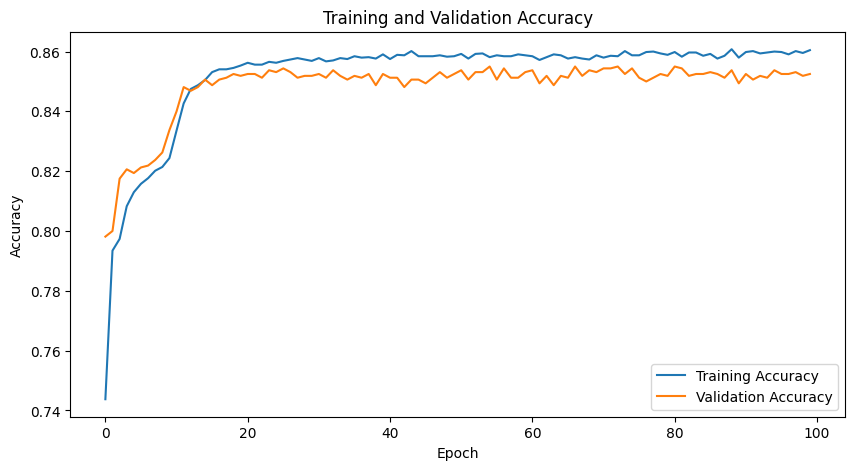

In [ ]:
# Accuracy Graphy
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

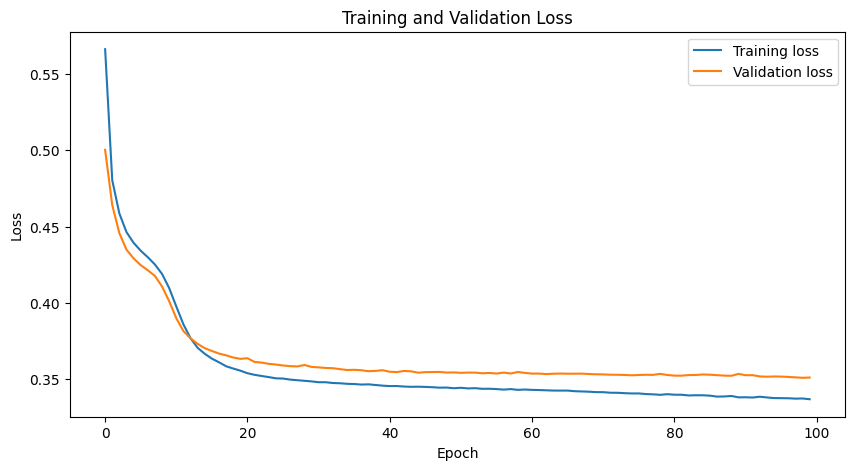

In [ ]:
# Loss Graph
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'],label='Training loss')
plt.plot(history.history['val_loss'],label='Validation loss')
plt.title('Training and Validation Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()